# Model training & evaluation analysis

This notebook lets you point at a single training run directory (for any head type: point, gauss, laplace, MC-dropout, etc.) and:

- Select one or more metrics (e.g. `mae_orig`, `rmse_orig`, `nll`) and plot Train/Val curves vs. epochs.
- Summarize train/val/test metrics at the best epoch in **target space**.
- Visualize test predictions (y_true vs y_pred, residuals) and, when available, uncertainty diagnostics (MC / probabilistic heads).

Edit `RUN_DIR` in the cell below to point at the run you want to analyze.

In [1]:
# Cell: imports and helpers

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception:
    widgets = None
    try:
        from IPython.display import display  # type: ignore
    except Exception:
        display = print

plt.style.use("seaborn-v0_8")

def _load_json(path: Path):
    with path.open("r") as f:
        return json.load(f)

def _safe_get(d, *keys, default=None):
    cur = d
    for k in keys:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

def _percent_delta(a, b):
    """Return (a-b)/b * 100, guarding against division by zero."""
    if b is None or not np.isfinite(b) or b == 0:
        return np.nan
    return 100.0 * (a - b) / b


In [2]:
# Cell: select training run directory
#
# Edit RUN_DIR below to point at the run you want to analyze.
# Example for a point run with best hparams:
#   outputs/trainings/training_point/point_290447

from pprint import pprint

RUN_DIR = Path("/home/canelo/uncertainty_quantification/outputs/trainings/training_gauss_50t_100e/gauss_50t_100e_290926")  # <-- change this

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"RUN_DIR does not exist: {RUN_DIR}")

# Derive job id from run directory name (e.g. point_290447 -> 290447)
RUN_TAG = RUN_DIR.name
job_id = None
parts = RUN_TAG.split("_")
if parts and parts[-1].isdigit():
    job_id = parts[-1]

# Resolve evals_root relative to this run's outputs/ directory
outputs_root = RUN_DIR.parents[2]  # .../outputs
evals_root = outputs_root / "evals"

EVAL_DIR = evals_root / RUN_TAG
if job_id is not None and evals_root.is_dir():
    candidates = sorted(evals_root.glob(f"*{job_id}*"))
    if candidates:
        EVAL_DIR = candidates[0]

print(f"RUN_DIR  : {RUN_DIR}")
print(f"RUN_TAG  : {RUN_TAG}")
print(f"EVAL_DIR : {EVAL_DIR} (may or may not exist, depending on eval_after_train)")

# Load configs and run summaries
used_cfg_path = RUN_DIR / "used_config.yaml"
metrics_json_path = RUN_DIR / "metrics.json"
run_meta_path = RUN_DIR / "run_meta.json"

if not used_cfg_path.is_file():
    raise FileNotFoundError(f"used_config.yaml not found at {used_cfg_path}")
if not metrics_json_path.is_file():
    raise FileNotFoundError(f"metrics.json not found at {metrics_json_path}")
if not run_meta_path.is_file():
    raise FileNotFoundError(f"run_meta.json not found at {run_meta_path}")

cfg = yaml.safe_load(used_cfg_path.read_text())
metrics_summary = _load_json(metrics_json_path)
run_meta = _load_json(run_meta_path)

head_type = cfg.get("model", {}).get("head_type", "point").lower()
hidden_dims = cfg.get("model", {}).get("hidden_dims")
activation = cfg.get("model", {}).get("activation")
dropout = cfg.get("model", {}).get("dropout")

train_cfg = cfg.get("training", {})
epochs = int(train_cfg.get("epochs", run_meta.get("epochs", 0)))
lr = train_cfg.get("lr")
weight_decay = train_cfg.get("weight_decay")
grad_clip = train_cfg.get("grad_clip")
eval_after_train = bool(train_cfg.get("eval_after_train", False))
mc_cfg = train_cfg.get("mc_eval", {}) or {}
mc_enabled = bool(mc_cfg.get("enabled", False))
n_mc_samples = mc_cfg.get("n_samples")
p_drop_override = mc_cfg.get("p_drop")

objective_name = metrics_summary.get("objective_name")
objective_val = metrics_summary.get("objective")
best_epoch = int(metrics_summary.get("best_epoch", run_meta.get("best_epoch", -1)))
train_time_sec = metrics_summary.get("train_time_sec", run_meta.get("train_time_sec"))

print("\n[run summary]")
print(f"head_type      : {head_type}")
print(f"hidden_dims    : {hidden_dims}")
print(f"activation     : {activation}")
print(f"dropout        : {dropout}")
print(f"epochs         : {epochs}")
print(f"lr, weight_decay, grad_clip : {lr}, {weight_decay}, {grad_clip}")
print(f"objective_name : {objective_name}")
print(f"objective      : {objective_val}")
print(f"best_epoch     : {best_epoch}")
print(f"train_time_sec : {train_time_sec}")
print(f"eval_after_train (deterministic eval) : {eval_after_train}")
print(f"mc_eval.enabled                      : {mc_enabled} (n_samples={n_mc_samples}, p_drop={p_drop_override})")


RUN_DIR  : /home/canelo/uncertainty_quantification/outputs/trainings/training_gauss_50t_100e/gauss_50t_100e_290926
RUN_TAG  : gauss_50t_100e_290926
EVAL_DIR : /home/canelo/uncertainty_quantification/outputs/evals/gauss_50t_100e_290926 (may or may not exist, depending on eval_after_train)

[run summary]
head_type      : gauss
hidden_dims    : [256, 256, 128]
activation     : gelu
dropout        : 0.15000000000000002
epochs         : 250
lr, weight_decay, grad_clip : 0.0018614552083813173, 0.0001885762826053872, 0.6000000000000001
objective_name : val_nll
objective      : 0.18927587382495403
best_epoch     : 218
train_time_sec : 576.022
eval_after_train (deterministic eval) : True
mc_eval.enabled                      : True (n_samples=50, p_drop=None)


In [3]:
# Cell: load per-epoch metrics and set up selectable metrics

metrics_csv_path = RUN_DIR / "metrics.csv"
if not metrics_csv_path.is_file():
    raise FileNotFoundError(f"metrics.csv not found at {metrics_csv_path}")

df_metrics = pd.read_csv(metrics_csv_path)
if "epoch" not in df_metrics.columns or "split" not in df_metrics.columns:
    raise ValueError("metrics.csv must contain at least 'epoch' and 'split' columns.")

print("metrics.csv columns:")
print(df_metrics.columns.tolist())

# Candidate metrics: focus on target-space metrics, but allow others if present.
preferred_order = [
    "mae_orig", "rmse_orig",  # primary target-space metrics
    "mae", "rmse",            # transformed-space
    "nll", "loss",
]
available_metrics = [m for m in preferred_order if m in df_metrics.columns]
if not available_metrics:
    raise RuntimeError("No known metric columns found in metrics.csv; cannot plot curves.")

print("\nAvailable metric choices:", available_metrics)

# Default selection: target-space metrics, falling back to mae if needed.
default_metrics = [m for m in ["mae_orig", "rmse_orig"] if m in available_metrics]
if not default_metrics:
    default_metrics = [available_metrics[0]]

if widgets is not None:
    metric_select = widgets.SelectMultiple(
        options=available_metrics,
        value=tuple(default_metrics),
        description="Metrics",
        disabled=False,
    )
    display(metric_select)
else:
    # Fallback: edit this list manually if you want more than the defaults
    SELECTED_METRICS = default_metrics
    print("\nipywidgets not available; using SELECTED_METRICS =", SELECTED_METRICS)


metrics.csv columns:
['epoch', 'split', 'loss', 'mae', 'rmse', 'mae_orig', 'rmse_orig', 'nll', 'elapsed_sec', 'timestamp', 'val_loss', 'objective']

Available metric choices: ['mae_orig', 'rmse_orig', 'mae', 'rmse', 'nll', 'loss']

ipywidgets not available; using SELECTED_METRICS = ['mae_orig', 'rmse_orig']


Plotting metrics: ['mae_orig', 'rmse_orig']


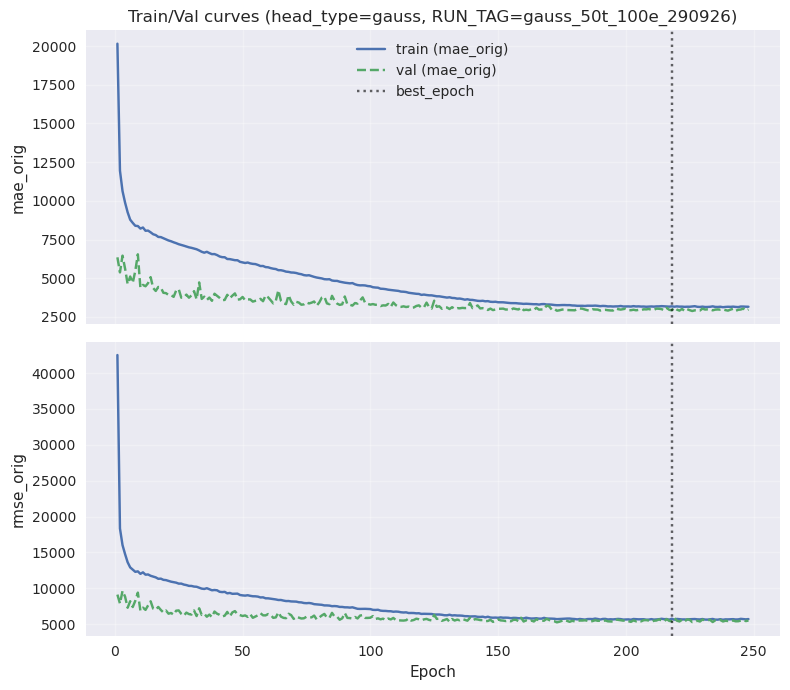

In [4]:
# Cell: Train/Val curves vs epoch (for selected metrics)

df_tv = df_metrics[df_metrics["split"].isin(["train", "val"])].copy()

if widgets is not None and "metric_select" in globals():
    selected = list(metric_select.value) or []
else:
    selected = globals().get("SELECTED_METRICS", [])

if not selected:
    selected = [m for m in ["mae_orig", "rmse_orig"] if m in df_metrics.columns] or [available_metrics[0]]

print("Plotting metrics:", selected)

n = len(selected)
fig, axes = plt.subplots(n, 1, figsize=(8, 3.5 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, metric in zip(axes, selected):
    for split_name, style in [("train", "-"), ("val", "--")]:
        sub = df_tv[df_tv["split"] == split_name]
        if metric not in sub.columns:
            continue
        ax.plot(sub["epoch"], sub[metric], style, label=f"{split_name} ({metric})")

    ax.axvline(best_epoch, color="k", linestyle=":", alpha=0.6, label="best_epoch")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Epoch")
axes[0].set_title(f"Train/Val curves (head_type={head_type}, RUN_TAG={RUN_TAG})")
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


In [5]:
# Cell: Train/Val/Test summary at best epoch (target space)

# Train/Val at best_epoch from metrics.csv
rows_best = df_metrics[df_metrics["epoch"] == best_epoch].copy()
tv_rows = rows_best[rows_best["split"].isin(["train", "val"])]
if tv_rows.empty:
    raise RuntimeError(f"No train/val rows at best_epoch={best_epoch} in metrics.csv")

target_space_metrics = [m for m in ["mae_orig", "rmse_orig"] if m in df_metrics.columns]
base_metrics = [m for m in ["mae", "rmse", "nll", "loss"] if m in df_metrics.columns]

records = []
for split_name in ["train", "val"]:
    row = tv_rows[tv_rows["split"] == split_name]
    if row.empty:
        continue
    row = row.iloc[0]
    rec = {"split": split_name, "epoch": int(row["epoch"])}
    for m in target_space_metrics + base_metrics:
        rec[m] = float(row[m]) if m in row and pd.notna(row[m]) else np.nan
    records.append(rec)

# Test metrics from eval dir (if available)
test_metrics_path = EVAL_DIR / "test_metrics.json"
test_rec = None
if test_metrics_path.is_file():
    test_payload = _load_json(test_metrics_path)
    tm = test_payload.get("test", {})
    rec = {"split": "test", "epoch": int(test_payload.get("best_epoch", best_epoch))}
    for m in target_space_metrics + base_metrics:
        rec[m] = float(tm.get(m, float("nan"))) if m in tm else np.nan
    records.append(rec)
    test_rec = rec
else:
    print(f"[warn] No test_metrics.json found at {test_metrics_path}; test row will be missing.")

df_summary = pd.DataFrame.from_records(records)
display(df_summary.set_index("split"))

if test_rec is not None:
    # Generalization gaps in target space
    gaps = {}
    for m in target_space_metrics:
        val_val = df_summary.loc[df_summary["split"] == "val", m].iloc[0] if "val" in df_summary["split"].values else np.nan
        test_val = test_rec.get(m, np.nan)
        gaps[m] = {
            "test_minus_val": test_val - val_val,
            "pct_vs_val": _percent_delta(test_val, val_val),
        }
    print("\n[generalization gap: test vs val, target space]")
    for m, g in gaps.items():
        print(f"  {m}: test - val = {g['test_minus_val']:.3f},  pct_vs_val = {g['pct_vs_val']:.2f}%")


,epoch,mae_orig,rmse_orig,mae,rmse,nll,loss
split,,,,,,,
train,218,3183.666700,5765.942900,0.238800,0.615600,-0.270900,-0.270900
val,218,2929.954300,5414.971200,0.224200,0.606200,0.189300,0.189300
test,218,2966.466064,5476.101074,0.234915,0.643786,0.299225,0.299225



[generalization gap: test vs val, target space]
  mae_orig: test - val = 36.512,  pct_vs_val = 1.25%
  rmse_orig: test - val = 61.130,  pct_vs_val = 1.13%


Using MC test predictions from: /home/canelo/uncertainty_quantification/outputs/evals/gauss_50t_100e_290926/mc_preds_test.csv


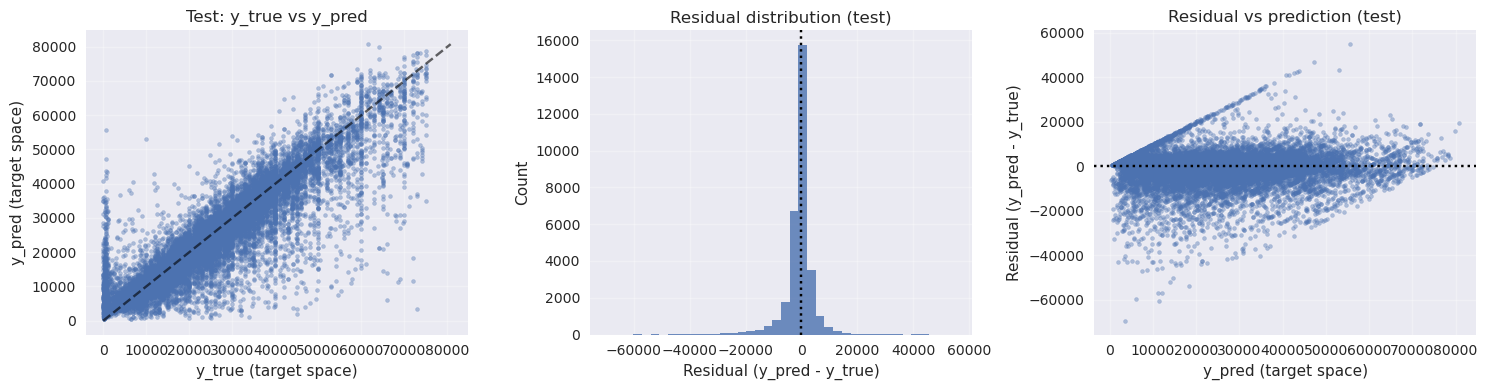

In [6]:
# Cell: Test predictions – overall picture (y_true vs y_pred, residuals)
# Handles point, probabilistic heads, and MC-dropout when available.

mc_test_path = EVAL_DIR / "mc_preds_test.csv"
det_test_path = EVAL_DIR / "test_preds.csv"

mode = None
df_test = None

if mc_test_path.is_file():
    mode = "mc"
    df_test = pd.read_csv(mc_test_path)
    print(f"Using MC test predictions from: {mc_test_path}")
elif det_test_path.is_file():
    mode = "det"
    df_test = pd.read_csv(det_test_path)
    print(f"Using deterministic test predictions from: {det_test_path}")
else:
    print(f"[warn] No test predictions found at {mc_test_path} or {det_test_path}; skipping plots.")

if df_test is not None:
    # Resolve y_true and y_pred in target space
    if mode == "mc":
        if "y_true" not in df_test.columns or "y_pred_mc_mean" not in df_test.columns:
            raise ValueError("mc_preds_test.csv must contain 'y_true' and 'y_pred_mc_mean'.")
        y_true = df_test["y_true"].to_numpy()
        y_pred = df_test["y_pred_mc_mean"].to_numpy()
        y_pred_det = df_test.get("y_pred_det")
        sigma_ale = df_test.get("sigma_ale_raw")
        sigma_epi = df_test.get("sigma_epi_raw")
    else:  # deterministic
        if "y_true" not in df_test.columns:
            raise ValueError("test_preds.csv must contain 'y_true'.")
        y_true = df_test["y_true"].to_numpy()
        if "y_pred" in df_test.columns:
            y_pred = df_test["y_pred"].to_numpy()
        elif "y_pred_det" in df_test.columns:
            y_pred = df_test["y_pred_det"].to_numpy()
        else:
            raise ValueError("Could not find y_pred column in deterministic test preds.")
        y_pred_det = None
        sigma_ale = df_test.get("y_scale")  # for some probabilistic heads
        sigma_epi = None

    residuals = y_pred - y_true

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1) y_true vs y_pred
    ax = axes[0]
    ax.scatter(y_true, y_pred, s=8, alpha=0.4)
    lims = [np.min([y_true.min(), y_pred.min()]), np.max([y_true.max(), y_pred.max()])]
    ax.plot(lims, lims, "k--", alpha=0.6)
    ax.set_xlabel("y_true (target space)")
    ax.set_ylabel("y_pred (target space)")
    ax.set_title("Test: y_true vs y_pred")
    ax.grid(True, alpha=0.3)

    # 2) Residual histogram
    ax = axes[1]
    ax.hist(residuals, bins=40, alpha=0.8)
    ax.axvline(0.0, color="k", linestyle=":")
    ax.set_xlabel("Residual (y_pred - y_true)")
    ax.set_ylabel("Count")
    ax.set_title("Residual distribution (test)")
    ax.grid(True, alpha=0.3)

    # 3) Residual vs prediction
    ax = axes[2]
    ax.scatter(y_pred, residuals, s=8, alpha=0.4)
    ax.axhline(0.0, color="k", linestyle=":")
    ax.set_xlabel("y_pred (target space)")
    ax.set_ylabel("Residual (y_pred - y_true)")
    ax.set_title("Residual vs prediction (test)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


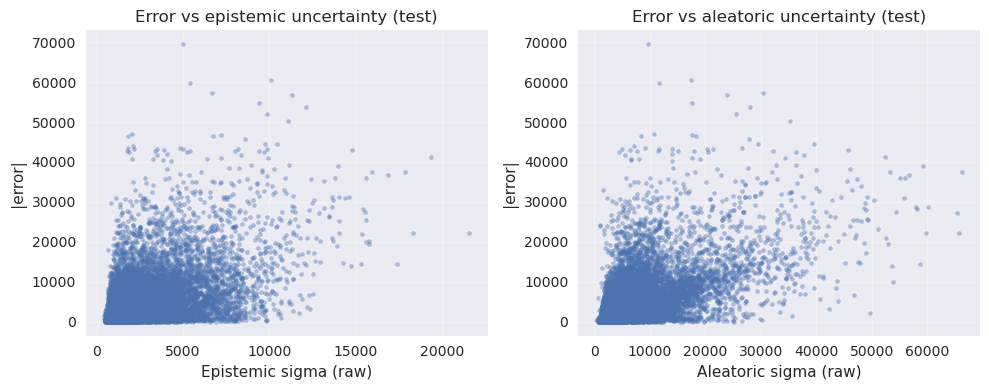

In [7]:
# Cell: Uncertainty diagnostics (only when uncertainty columns are available)
# - For MC-dropout heads: use sigma_ale_raw / sigma_epi_raw
# - For probabilistic heads (gauss/laplace): use y_scale or similar

if df_test is not None:
    # Try MC-style columns first
    has_mc_unc = ("sigma_ale_raw" in df_test.columns) or ("sigma_epi_raw" in df_test.columns)
    has_scale = ("y_scale" in df_test.columns)

    if not (has_mc_unc or has_scale):
        print("No uncertainty columns (sigma_ale_raw / sigma_epi_raw / y_scale) found; skipping uncertainty plots.")
    else:
        y_true_u = df_test["y_true"].to_numpy()
        if "y_pred_mc_mean" in df_test.columns:
            y_pred_u = df_test["y_pred_mc_mean"].to_numpy()
        elif "y_pred" in df_test.columns:
            y_pred_u = df_test["y_pred"].to_numpy()
        elif "y_pred_det" in df_test.columns:
            y_pred_u = df_test["y_pred_det"].to_numpy()
        else:
            y_pred_u = df_test.iloc[:, df_test.columns.get_loc("y_true") + 1].to_numpy()

        abs_err = np.abs(y_pred_u - y_true_u)

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        idx_ax = 0

        if "sigma_epi_raw" in df_test.columns:
            sigma_epi = df_test["sigma_epi_raw"].to_numpy()
            ax = axes[idx_ax]
            idx_ax += 1
            ax.scatter(sigma_epi, abs_err, s=8, alpha=0.4)
            ax.set_xlabel("Epistemic sigma (raw)")
            ax.set_ylabel("|error|")
            ax.set_title("Error vs epistemic uncertainty (test)")
            ax.grid(True, alpha=0.3)

        if "sigma_ale_raw" in df_test.columns:
            sigma_ale = df_test["sigma_ale_raw"].to_numpy()
            ax = axes[idx_ax]
            idx_ax += 1
            ax.scatter(sigma_ale, abs_err, s=8, alpha=0.4)
            ax.set_xlabel("Aleatoric sigma (raw)")
            ax.set_ylabel("|error|")
            ax.set_title("Error vs aleatoric uncertainty (test)")
            ax.grid(True, alpha=0.3)

        # If only one of the above plotted, hide the unused axis
        if idx_ax == 1:
            axes[1].set_visible(False)

        plt.tight_layout()
        plt.show()
